# Pre-trained models with `xnn`: the model hub & `from_pretrained()`

`xnn.common.models.hub` is the model-side twin of the dataset hub: a
**HuggingFace `from_pretrained()`-style one-liner** that loads any pre-trained
interatomic potential, whatever its origin, under one API:

```python
from xnn.common.models import from_pretrained, list_models

model = from_pretrained("mace-off23-small")                    # MACE foundation model
model = from_pretrained("mace-mh-0", head="omat_pbe")          # one head of a multi-head model
model = from_pretrained("xnn-mace-argon")                      # a model trained with xnn
model = from_pretrained("doi:10.5281/zenodo.18957344",         # a model published on Zenodo
                        filename="mace_csfapbbri_al_5_1_stagetwo.model")
model = from_pretrained("runs/exp/best.pt")                    # a local trainer checkpoint
```

The first call downloads the file (MD5-verified) into a cache directory of your
choice (`cache_dir=`), converts foreign formats such as `mace-torch` **once**,
and stores the result as a **portable model directory**: `card.json`,
`config.yaml`, `model.pt`, with no pickled Python objects and no absolute
paths. Later calls load that directory offline, without the upstream package,
and the directory can be copied to another machine and used there as is.

This notebook walks through:

1. Discovering the available models (`list_models`, model cards)
2. The one-liner and what lands in the cache
3. Using a foundation model on molecules: the S22 water dimer
4. A materials foundation model: the silicon equation of state
5. Multi-head models: one head per level of theory
6. A model trained with `xnn`: liquid argon
7. Models published on Zenodo, scored on the record's own DFT test set
8. Portability: copying a cache to another machine
9. Sharing your own models (`save_pretrained`, `xnn models pack`, the registry)
10. The same names everywhere: ASE, MDI, `MACE.from_foundation`, the CLI

## 0. Setup

Everything this notebook downloads or converts goes into `runs/model_cache/`
next to it (passed as `cache_dir=`), which is cleared first so the conversions
below happen in front of you. The `xnn-mace-argon` model of section 6 is read
from the default cache instead. Logged warnings are shown, so the license notice
of ASL-licensed models appears; the TorchScript warnings e3nn emits while
building its modules, and the import banner of `mace-torch`, are silenced.

In [1]:
import json
import logging
import shutil
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

warnings.filterwarnings("ignore", category=FutureWarning)
# e3nn's compiled tensor products warn once per module built; harmless
warnings.filterwarnings("ignore", message="The TorchScript type system")
warnings.filterwarnings("ignore", category=UserWarning, module="torch.jit")
# mace-torch (needed only to convert upstream checkpoints) prints a banner on import
import contextlib, io
with contextlib.redirect_stdout(io.StringIO()):
    try:
        import mace.modules  # noqa: F401
    except ImportError:
        pass
logging.basicConfig(level=logging.WARNING, format="%(levelname)s %(name)s: %(message)s")
pd.set_option("display.max_colwidth", 70)

from xnn.common.models import (from_pretrained, list_models, load_pretrained, model_card,
                               register_pretrained, save_pretrained)
from xnn.common.models.hub import default_model_cache_dir, fetch_model

CACHE = Path("runs/model_cache")
shutil.rmtree(CACHE, ignore_errors=True)
print("notebook cache:", CACHE.resolve())
print("default cache: ", default_model_cache_dir())


def tree(root, max_depth=3):
    # print a directory tree with file sizes
    root = Path(root)
    for p in sorted(root.rglob("*")):
        depth = len(p.relative_to(root).parts)
        if depth > max_depth:
            continue
        size = f"  ({p.stat().st_size / 1e6:.2f} MB)" if p.is_file() else "/"
        print("    " * (depth - 1) + p.name + size)

notebook cache: /D3/sina/xnns/examples/models/runs/model_cache
default cache:  /D3/sina/xnns/models


## 1. What models are available?

`list_models()` lists the **registry** (the `models.json` file shipped inside
the package, plus anything added with `register_pretrained`) together with
every model directory found in the cache. With `details=True` it returns one
row per model; the `cached` column says what is on disk already: `ready`
(loads offline), `raw` (the upstream file is on disk and is converted on first
load; here the files `mace-torch` keeps in `~/.cache/mace` are reused),
an empty cell (needs a download), or `unsupported`.

In [2]:
rows = pd.DataFrame(list_models(details=True)).set_index("name")
rows

,architecture,format,cutoff,elements,heads,license,cached,description
name,,,,,,,,
mace-matpes-pbe-0-medium,mace,mace-torch,6.0,89,,ASL,raw,MACE-MATPES-PBE-0 medium: MACE-OMAT-0 fine-tuned on MatPES (PBE)
mace-matpes-r2scan-0-medium,mace,mace-torch,6.0,89,,ASL,raw,MACE-MATPES-r2SCAN-0 medium: MACE-OMAT-0 fine-tuned on MatPES (r2S...
mace-mh-0,mace,mace-torch,6.0,89,7,MIT,raw,"MACE-MH-0: multi-head foundation model, one head per training set ..."
mace-mh-1,mace,mace-torch,6.0,89,6,MIT,unsupported,"MACE-MH-1: multi-head foundation model, next architecture generation"
mace-mp-0-large,mace,mace-torch,4.5,89,,MIT,raw,MACE-MP-0 large: universal materials potential trained on MPtrj (P...
mace-mp-0-medium,mace,mace-torch,6.0,89,,MIT,raw,MACE-MP-0 medium: universal materials potential trained on MPtrj (...
mace-mp-0-small,mace,mace-torch,6.0,89,,MIT,raw,MACE-MP-0 small: universal materials potential trained on MPtrj (P...
mace-mp-0b-medium,mace,mace-torch,6.0,89,,MIT,raw,"MACE-MP-0b medium: MPtrj, with the Agnesi distance transform and Z..."
mace-mp-0b-small,mace,mace-torch,6.0,89,,MIT,raw,"MACE-MP-0b small: MPtrj, with the Agnesi distance transform and ZB..."


Filters narrow the list by format, architecture or tag, and `model_card()`
returns the full card of one model: where it comes from, its license and
citation, cutoff, elements, heads and dtype.

In [3]:
print("organic: ", list_models(tag="organic"))
print("xnn:     ", list_models(format="xnn"))
print("in cache:", list_models(CACHE, cached_only=True)[:3], "...")

card = model_card("mace-off23-small").to_dict()
card["species"] = f"{len(card['species'])} elements: {card['species']}"
print(json.dumps(card, indent=2))

organic:  ['mace-off23-large', 'mace-off23-medium', 'mace-off23-small']
xnn:      ['xnn-mace-argon']
in cache: ['mace-matpes-pbe-0-medium', 'mace-matpes-r2scan-0-medium', 'mace-mh-0'] ...
{
  "name": "mace-off23-small",
  "description": "MACE-OFF23 small: organic molecules (H C N O F P S Cl Br I), trained on SPICE at wB97M-D3(BJ)",
  "format": "mace-torch",
  "architecture": "mace",
  "cutoff": 4.5,
  "species": "10 elements: [1, 6, 7, 8, 9, 15, 16, 17, 35, 53]",
  "dtype": "float64",
  "units": {
    "energy": "eV",
    "length": "angstrom"
  },
  "license": "ASL",
  "citation": "D. P. Kovacs et al., MACE-OFF23: Transferable machine learning force fields for organic molecules, arXiv:2312.15211 (2023)",
  "url": "https://raw.githubusercontent.com/ACEsuit/mace-off/main/mace_off23/MACE-OFF23_small.model",
  "md5": "1335345ad7e027c760cb8db673321940",
  "tags": [
    "foundation",
    "organic"
  ]
}


## 2. The one-liner

`from_pretrained(name)` returns the model wrapped in `ForceStressOutput`
(energies plus autograd forces, and stress with `compute_stress=True`), in eval
mode and in the checkpoint's own dtype. `wrap=False` returns the bare
potential.

The first call below finds the upstream `MACE-OFF23_small.model` (in
`mace-torch`'s cache, or downloads it), converts it weight for weight into the
xnn `MACE`, and writes the converted model to the cache.

In [4]:
t0 = time.perf_counter()
model = from_pretrained("mace-off23-small", cache_dir=CACHE)
t_first = time.perf_counter() - t0
print(f"{type(model).__name__}({type(model.model).__name__}) | cutoff {model.cutoff} A | "
      f"{next(model.parameters()).dtype} | {sum(p.numel() for p in model.parameters()):,} "
      f"parameters | first load {t_first:.1f} s")

WARNING xnn.common.models.hub.loader: mace-off23-small is distributed under the Academic Software License (https://github.com/gabor1/ASL); by using it you accept its terms (no commercial use).


ForceStressOutput(MACE) | cutoff 4.5 A | torch.float64 | 694,520 parameters | first load 2.0 s


The second call reads the converted directory. `local_files_only=True` (or the
`XNN_OFFLINE=1` environment variable) guarantees that nothing touches the
network, and the cached copy needs neither `mace-torch` nor the original file.

In [5]:
t0 = time.perf_counter()
model = from_pretrained("mace-off23-small", cache_dir=CACHE, local_files_only=True)
print(f"cached load {time.perf_counter() - t0:.1f} s (first: {t_first:.1f} s)")
tree(CACHE)

cached load 0.9 s (first: 2.0 s)
mace-off23-small/
    card.json  (0.00 MB)
    config.yaml  (0.00 MB)
    model.pt  (7.17 MB)


### Anatomy of a model directory

`card.json` is the model card (with an MD5 per file), `config.yaml` the plain
YAML configuration that rebuilds the architecture, and `model.pt` the weights,
saved as a bare tensor dictionary that `torch.load(..., weights_only=True)`
reads.

In [6]:
slot = CACHE / "mace-off23-small"
card = json.loads((slot / "card.json").read_text())
card["species"] = f"[{len(card['species'])} elements]"
print(json.dumps(card, indent=2))
print("\n".join((slot / "config.yaml").read_text().splitlines()[:24]))
weights = torch.load(slot / "model.pt", weights_only=True)["model"]
print(f"... model.pt: {len(weights)} tensors, loaded with weights_only=True")

{
  "name": "mace-off23-small",
  "description": "MACE-OFF23 small: organic molecules (H C N O F P S Cl Br I), trained on SPICE at wB97M-D3(BJ)",
  "format": "xnn",
  "architecture": "mace",
  "cutoff": 4.5,
  "species": "[10 elements]",
  "dtype": "float64",
  "units": {
    "energy": "eV",
    "length": "angstrom"
  },
  "license": "ASL",
  "citation": "D. P. Kovacs et al., MACE-OFF23: Transferable machine learning force fields for organic molecules, arXiv:2312.15211 (2023)",
  "url": "https://raw.githubusercontent.com/ACEsuit/mace-off/main/mace_off23/MACE-OFF23_small.model",
  "tags": [
    "foundation",
    "organic"
  ],
  "source": "https://raw.githubusercontent.com/ACEsuit/mace-off/main/mace_off23/MACE-OFF23_small.model",
  "files": {
    "config.yaml": "a8e0fc827f437cb53824ceecfe710252",
    "model.pt": "5e148f0eb605125794cf83f8812e5f79"
  },
  "xnn_version": "0.4.0"
}
model:
  name: mace
  cutoff: 4.5
  n_features: 96
  n_interactions: 2
  n_rbf: 8
  extra:
    species:
    - 

## 3. A foundation model on molecules: the S22 water dimer

`XNNCalculator.from_pretrained` builds an ASE calculator from the same names.
The water dimer of the S22 set has a CCSD(T)/CBS interaction energy of
-0.2177 eV (-5.02 kcal/mol); MACE-OFF23 was trained on SPICE
(wB97M-D3(BJ)).

In [7]:
from ase.data.s22 import create_s22_system, get_interaction_energy_cc
from ase.optimize import BFGS

from xnn.common.deploy import XNNCalculator

calc = XNNCalculator.from_pretrained("mace-off23-small", cache_dir=CACHE)

dimer = create_s22_system("Water_dimer")
def energy(atoms):
    atoms = atoms.copy()
    atoms.calc = calc
    return atoms.get_potential_energy()

e_int = energy(dimer) - energy(dimer[:3]) - energy(dimer[3:])
ref = get_interaction_energy_cc("Water_dimer")
print(f"interaction energy at the S22 geometry: MACE-OFF23-small {e_int:.4f} eV "
      f"({e_int * 23.0605:.2f} kcal/mol) | CCSD(T)/CBS {ref:.4f} eV ({ref * 23.0605:.2f} kcal/mol)")

relaxed = dimer.copy()
relaxed.calc = calc
BFGS(relaxed, logfile=None).run(fmax=0.01)
d_oo = relaxed.get_distance(0, 3)
print(f"relaxed dimer: O-O {d_oo:.3f} A (S22: {dimer.get_distance(0, 3):.3f} A), "
      f"max force {np.abs(relaxed.get_forces()).max():.4f} eV/A")

interaction energy at the S22 geometry: MACE-OFF23-small -0.2077 eV (-4.79 kcal/mol) | CCSD(T)/CBS -0.2177 eV (-5.02 kcal/mol)


relaxed dimer: O-O 2.933 A (S22: 2.910 A), max force 0.0045 eV/A


## 4. A materials foundation model: the silicon equation of state

The MACE-MP series covers 89 elements. With `mace-mp-0-small` (trained on the
PBE/PBE+U MPtrj set) we scan the lattice parameter of diamond silicon and fit
an equation of state, to compare with PBE (lattice parameter near 5.47 A,
bulk modulus near 89 GPa) and experiment (5.431 A, 98 GPa).

a0 = 5.465 A | B0 = 74.4 GPa | E0 = -5.371 eV/atom


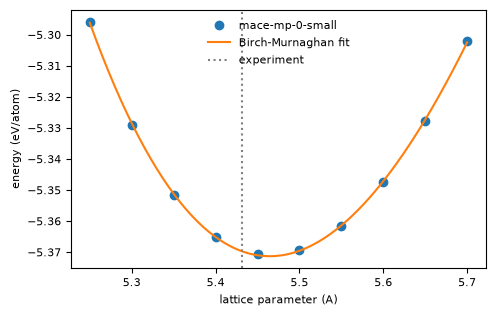

In [8]:
from ase.build import bulk
from ase.eos import EquationOfState
from ase.units import GPa

calc_mp = XNNCalculator.from_pretrained("mace-mp-0-small", cache_dir=CACHE)
lattice = np.linspace(5.25, 5.70, 10)
volumes, energies = [], []
for a in lattice:
    si = bulk("Si", "diamond", a=a)
    si.calc = calc_mp
    volumes.append(si.get_volume())
    energies.append(si.get_potential_energy())
eos = EquationOfState(volumes, energies, eos="birchmurnaghan")
v0, e0, b0 = eos.fit()
a0 = (4 * v0) ** (1 / 3)        # 2-atom primitive cell: V = a^3 / 4
print(f"a0 = {a0:.3f} A | B0 = {b0 / GPa:.1f} GPa | E0 = {e0 / 2:.3f} eV/atom")

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(lattice, np.array(energies) / 2, "o", label="mace-mp-0-small")
fine = np.linspace(volumes[0], volumes[-1], 200)
ax.plot((4 * fine) ** (1 / 3), eos.func(fine, *eos.eos_parameters) / 2, "-", label="Birch-Murnaghan fit")
ax.axvline(5.431, color="gray", ls=":", label="experiment")
ax.set_xlabel("lattice parameter (A)")
ax.set_ylabel("energy (eV/atom)")
ax.legend(frameon=False)
plt.tight_layout()

The lattice parameter lands on the PBE value, while the bulk modulus comes out
softer than PBE: the curvature of the energy surface is underestimated, the
systematic softening known for universal potentials and most pronounced in
the small models. The larger `mace-mp-0-medium` / `mace-mpa-0-medium` load the
same way.

## 5. Multi-head models

`mace-mh-0` carries seven heads, one per training set and level of theory. A
head is chosen at load time; each converted head gets its own directory under
`<cache>/mace-mh-0/heads/`. Without a head the loader stops before any download
and lists the options.

In [9]:
try:
    from_pretrained("mace-mh-0", cache_dir=CACHE)
except ValueError as e:
    print("ValueError:", e)

ValueError: mace-mh-0 has 7 heads; pass head= with one of ['rgd1_b3lyp', 'matpes_r2scan', 'mp_pbe_refit_add', 'omol', 'spice_wB97M', 'oc20_usemppbe', 'omat_pbe']


The same water dimer through three heads, each trained on a different level of
theory: two molecular heads (`spice_wB97M`: wB97M-D3(BJ) on SPICE; `omol`) and
the materials head `omat_pbe` (PBE).

In [10]:
for head in ("spice_wB97M", "omol", "omat_pbe"):
    calc_h = XNNCalculator.from_pretrained("mace-mh-0", head=head, cache_dir=CACHE)
    parts = []
    for atoms in (dimer, dimer[:3], dimer[3:]):
        atoms = atoms.copy()
        atoms.calc = calc_h
        parts.append(atoms.get_potential_energy())
    e = parts[0] - parts[1] - parts[2]
    print(f"{head:12s} {e:8.4f} eV ({e * 23.0605:6.2f} kcal/mol)   [{calc_h.dtype}]")
print(f"{'CCSD(T)/CBS':12s} {ref:8.4f} eV ({ref * 23.0605:6.2f} kcal/mol)")
tree(CACHE / "mace-mh-0")

spice_wB97M   -0.2173 eV ( -5.01 kcal/mol)   [torch.float32]


omol          -0.2148 eV ( -4.95 kcal/mol)   [torch.float32]


omat_pbe      -0.2284 eV ( -5.27 kcal/mol)   [torch.float32]
CCSD(T)/CBS   -0.2177 eV ( -5.02 kcal/mol)
heads/
    omat_pbe/
        card.json  (0.00 MB)
        config.yaml  (0.00 MB)
        model.pt  (39.63 MB)
    omol/
        card.json  (0.00 MB)
        config.yaml  (0.00 MB)
        model.pt  (39.63 MB)
    spice_wB97M/
        card.json  (0.00 MB)
        config.yaml  (0.00 MB)
        model.pt  (39.63 MB)


The molecular heads land within 0.1 kcal/mol of the coupled-cluster value; the
PBE head overbinds a little, as PBE itself does for hydrogen bonds. The
checkpoint stores float32 weights, so these heads serve in float32 unless
`dtype=torch.float64` is passed. Its upstream file sits in `mace-torch`'s
cache here, so no `raw/` copy was made; a fresh download is kept in
`mace-mh-0/raw/` for converting the other heads.

## 6. A model trained with `xnn`: liquid argon

`xnn-mace-argon` is the MACE model of the MDI deployment examples, trained on
the `argon_md` set (400-atom periodic frames). Its registry entry has no DOI
yet, so it loads only where it is cached: this repository's default cache
holds the packed copy. Asking for it in a cache that does not have it gives a
clear error rather than a download attempt.

In [11]:
try:
    from_pretrained("xnn-mace-argon", cache_dir=CACHE)
except FileNotFoundError as e:
    print("FileNotFoundError:", e)

argon = load_pretrained("xnn-mace-argon")          # default cache
print(f"\nloaded from {argon.path} | {argon.card.description}")
print(f"trained on {argon.config.data.batch_size}-frame batches, lr {argon.config.optim.lr}, "
      f"{argon.config.optim.epochs} epochs")

FileNotFoundError: xnn-mace-argon is registered but has no download source yet (its card names no DOI or URL) and is not cached in runs/model_cache



loaded from /D3/sina/xnns/models/xnn-mace-argon | MACE (2 layers, 32 channels, 6 A cutoff) trained on the argon_md liquid-argon set; the model of the MDI deployment examples
trained on 10-frame batches, lr 0.01, 30 epochs


`load_pretrained` returns the model together with its config, card and cutoff.
The config shows how it was trained: forces weighted
100 times more than energies, the usual choice for a model meant for molecular
dynamics. Scored on the held-out test frames of `argon_md`:

loss weights: energy 1.0, forces 100.0
50 frames | energy MAE 13.41 meV/atom (mean signed -9.7) | force MAE 1.6 meV/A


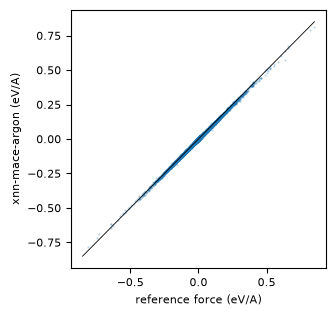

In [12]:
from xnn.common.data import load_dataset, structure_to_graph

test = load_dataset("argon_md", split="test")
de, f_ref, f_pred = [], [], []
for s in test:
    g = structure_to_graph(s, argon.cutoff)
    out = argon.model(g)
    de.append((float(out["energy"]) - s["energy"]) / len(s["atomic_numbers"]))
    f_ref.append(np.asarray(s["forces"]))
    f_pred.append(out["forces"].detach().numpy())
f_ref, f_pred = np.concatenate(f_ref), np.concatenate(f_pred)
print(f"loss weights: energy {argon.config.optim.energy_weight}, forces {argon.config.optim.force_weight}")
print(f"{len(test)} frames | energy MAE {np.abs(de).mean() * 1e3:.2f} meV/atom "
      f"(mean signed {np.mean(de) * 1e3:+.1f}) | force MAE {np.abs(f_pred - f_ref).mean() * 1e3:.1f} meV/A")

fig, ax = plt.subplots(figsize=(3.4, 3.2))
ax.plot(f_ref.ravel(), f_pred.ravel(), ".", ms=1, alpha=0.3)
lim = np.abs(f_ref).max()
ax.plot([-lim, lim], [-lim, lim], "k-", lw=0.6)
ax.set_xlabel("reference force (eV/A)")
ax.set_ylabel("xnn-mace-argon (eV/A)")
plt.tight_layout()

The forces, which drive the dynamics, are accurate to a few meV/A; the absolute
per-atom energies scatter by about 15 meV/atom, the price of the force-heavy
loss. The card's `notes` field says as much, so `list_models` users know what
they are getting.

## 7. Models published on Zenodo

Any Zenodo DOI or record link works as a source: `doi:10.5281/zenodo.N`,
`https://doi.org/10.5281/zenodo.N`, `https://zenodo.org/records/N`, or a
`.../records/N/files/<file>` link that picks the file. The record metadata
comes from Zenodo's API, which also supplies the MD5 of every file and fills
the card's description, license and citation.

Record [10.5281/zenodo.18957344](https://doi.org/10.5281/zenodo.18957344)
(Laakso, Tiihonen and Rinke, CC-BY-4.0) holds two MACE models for
(Cs/FA)B(Cl/Br/I)3 hybrid perovskite alloys together with their DFT training
and test sets. A record with several model files needs `filename=`:

In [13]:
DOI = "doi:10.5281/zenodo.18957344"
try:
    fetch_model(DOI, cache_dir=CACHE)
except ValueError as e:
    print("ValueError:", e)

ValueError: Zenodo record 18957344 holds several model files; pass filename= with one of ['mace_csfapbbri_al_5_1_stagetwo.model', 'mace_csfasnbri_al_5_0_stagetwo.model']


In [14]:
pero = load_pretrained(DOI, filename="mace_csfapbbri_al_5_1_stagetwo.model", cache_dir=CACHE)
print(f"name     {pero.card.name}\nlicense  {pero.card.license}\ncitation {pero.card.citation}")
print(f"cutoff   {pero.cutoff} A | elements {pero.card.species} | {pero.card.dtype}")
tree(CACHE / "zenodo.18957344")

mace_csfapbbri_al_5_1_stagetwo.model:   0%|          | 0.00/3.46M [00:00<?, ?B/s]

name     zenodo.18957344/mace_csfapbbri_al_5_1_stagetwo.model
license  cc-by-4.0
citation Laakso, Jarno et al. (2026). (Cs/FA)B(Cl/Br/I)3 Hybrid Perovskite Alloy DFT Datasets and MACE Models. Zenodo. https://doi.org/10.5281/zenodo.18957344
cutoff   5.0 A | elements [1, 6, 7, 35, 53, 55, 82] | float32
mace_csfapbbri_al_5_1_stagetwo.model/
    card.json  (0.00 MB)
    config.yaml  (0.00 MB)
    model.pt  (3.40 MB)
record.json  (0.01 MB)


The record ships the DFT test set of this model, so we can check that the
conversion reproduces the published accuracy. The file comes through the same
cached, MD5-verified downloader the dataset hub uses.

In [15]:
from ase.io import read

from xnn.common.data.hub._download import download_file
from xnn.common.models.hub import zenodo

record = json.loads((CACHE / "zenodo.18957344" / "record.json").read_text())
entry = next(f for f in zenodo.files(record) if f["key"] == "csfapbbri_test.xyz")
xyz = download_file(entry["url"], CACHE / "perovskite_data" / entry["key"], md5=entry["md5"])

frames = read(xyz, ":")
calc_p = XNNCalculator.from_pretrained("zenodo.18957344/mace_csfapbbri_al_5_1_stagetwo.model",
                                       cache_dir=CACHE, local_files_only=True)
de, f_ref, f_pred = [], [], []
for atoms in frames:
    e_dft, f_dft = atoms.get_potential_energy(), atoms.get_forces()
    atoms.calc = calc_p
    de.append((atoms.get_potential_energy() - e_dft) / len(atoms))
    f_ref.append(f_dft)
    f_pred.append(atoms.get_forces())
f_ref, f_pred = np.concatenate(f_ref), np.concatenate(f_pred)
print(f"{len(frames)} DFT test frames ({min(map(len, frames))}-{max(map(len, frames))} atoms) | "
      f"energy MAE {np.abs(de).mean() * 1e3:.2f} meV/atom | "
      f"force MAE {np.abs(f_pred - f_ref).mean() * 1e3:.1f} meV/A")

csfapbbri_test.xyz:   0%|          | 0.00/1.44M [00:00<?, ?B/s]

200 DFT test frames (40-96 atoms) | energy MAE 0.40 meV/atom | force MAE 10.5 meV/A


The cached model now answers to its record link and to its cache key, offline:

In [16]:
link = "https://zenodo.org/records/18957344/files/mace_csfapbbri_al_5_1_stagetwo.model"
print(fetch_model(link, cache_dir=CACHE, local_files_only=True))
print(fetch_model("zenodo.18957344/mace_csfapbbri_al_5_1_stagetwo.model", cache_dir=CACHE,
                  local_files_only=True))

runs/model_cache/zenodo.18957344/mace_csfapbbri_al_5_1_stagetwo.model
runs/model_cache/zenodo.18957344/mace_csfapbbri_al_5_1_stagetwo.model


## 8. Portability: copying a cache to another machine

A model directory holds everything needed to rebuild the model and nothing
tied to the machine that wrote it. Copy one (or the whole cache) anywhere,
point `cache_dir` (or `XNN_MODELS`) at the new location, and it loads by name.
Here a second directory stands in for another machine; the MD5 digests in the
card confirm the copy is intact.

In [17]:
import hashlib

elsewhere = Path("runs/other_machine/models")
shutil.rmtree(elsewhere.parent, ignore_errors=True)
shutil.copytree(CACHE / "mace-off23-small", elsewhere / "mace-off23-small")
shutil.copytree(CACHE / "zenodo.18957344", elsewhere / "zenodo.18957344")

card = model_card("mace-off23-small")
copied = json.loads((elsewhere / "mace-off23-small" / "card.json").read_text())
for name, md5 in copied["files"].items():
    ok = hashlib.md5((elsewhere / "mace-off23-small" / name).read_bytes()).hexdigest() == md5
    print(f"{name:12s} md5 {'ok' if ok else 'MISMATCH'}")

moved = from_pretrained("mace-off23-small", cache_dir=elsewhere, local_files_only=True)
probe = structure_to_graph({"pos": dimer.positions, "atomic_numbers": dimer.numbers}, moved.cutoff)
probe.pos = probe.pos.double()
print("same energies:", float(moved(probe)["energy"]) == float(model(probe)["energy"]))
print("ready there:  ", [r["name"] for r in list_models(elsewhere, details=True)
                         if r["cached"] == "ready"])

config.yaml  md5 ok
model.pt     md5 ok


same energies: True
ready there:   ['mace-off23-small', 'zenodo.18957344/mace_csfapbbri_al_5_1_stagetwo.model']


Environment variables set the defaults: `XNN_MODELS` is the cache directory
(`XNN_CACHE/models` if only `XNN_CACHE` is set; otherwise the repository's
`models/` directory in a source checkout, `~/.cache/xnn/models` in an
installed package), and `XNN_OFFLINE=1` forbids network access everywhere.

## 9. Sharing your own models

`save_pretrained` writes any model, or any checkpoint the hub reads, as a
portable directory. From a training run it is one line,
`trainer.save_pretrained("my-model", description=..., license=...)`; for an
existing `best.pt`:

In [18]:
packed = save_pretrained("../deploy/runs/mdi_argon/best.pt", CACHE / "my-argon",
                         description="MACE for liquid argon (my lab)", license="MIT",
                         citation="Me et al. (2026)", tags=["argon"])
tree(packed)
print(model_card("my-argon", CACHE).description)

card.json  (0.00 MB)
config.yaml  (0.00 MB)
model.pt  (3.62 MB)
MACE for liquid argon (my lab)


The `xnn models` command does the same from a shell, and `--archive` adds a
`.zip` ready to upload:

```bash
xnn models pack runs/exp/best.pt my-model --description "..." --license MIT --archive
```

To publish, upload the three files of the directory (or the zip) to Zenodo.
`from_pretrained("doi:10.5281/zenodo.<id>")` then works for everyone, and an
entry with that `doi` in `src/xnn/common/models/hub/models.json` (or a
`register_pretrained` call) gives it a short name. Below, a `file://` URL
stands in for the upload, to show the whole path: register, download, unpack,
cache, load.

In [19]:
import subprocess
import sys

run = subprocess.run([sys.executable, "-m", "xnn.common.cli.main", "models", "pack",
                      "../deploy/runs/mdi_argon/best.pt", "runs/upload/lab-argon",
                      "--description", "MACE for liquid argon", "--license", "MIT",
                      "--archive"], capture_output=True, text=True)
print(run.stdout.strip())

register_pretrained(name="lab-argon", url=Path("runs/upload/lab-argon.zip").resolve().as_uri(),
                    description="MACE for liquid argon", license="MIT", architecture="mace")
lab = load_pretrained("lab-argon", cache_dir=CACHE, quiet=True)
print("loaded", lab.card.name, "from", lab.path, "| source:", lab.card.source.split("/")[-1])

wrote runs/upload/lab-argon
wrote /D3/sina/xnns/examples/models/runs/upload/lab-argon.zip


loaded lab-argon from runs/model_cache/lab-argon | source: lab-argon.zip


## 10. The same names everywhere

Everything that loads a model goes through the hub, so a registered name, a
DOI or a cache key works wherever a checkpoint path did:

* `XNNCalculator.from_pretrained(...)` (above) and `Model.from_pretrained(...)`
  for the bare potential of a given class,
* `MDIEngine.from_checkpoint(...)` and `xnn mdi --ckpt mace-off23-small ...`,
* `xnn export --ckpt mace-off23-small --to lammps`,
* a benchmark YAML entry `checkpoint: mace-off23-small`,
* `MACE.from_foundation("mace-off23-small")` and the config form
  `model: {name: mace, foundation: mace-off23-small}`.

In [20]:
from xnn.common.deploy import MDIEngine
from xnn.gnn.models.mace import MACE

engine = MDIEngine.from_checkpoint("mace-off23-small", cache_dir=CACHE)
print("MDI engine:      cutoff", engine.cutoff, "|", engine.dtype)
bare = MACE.from_pretrained("mace-off23-small", cache_dir=CACHE)
via_foundation = MACE.from_foundation("mace-off23-small", cache_dir=CACHE)
print("MACE classes:   ", type(bare).__name__, type(via_foundation).__name__)

run = subprocess.run([sys.executable, "-m", "xnn.common.cli.main", "models", "list", "--cached",
                      "--format", "xnn", "--cache-dir", str(CACHE)], capture_output=True, text=True)
print(run.stdout)

MDI engine:      cutoff 4.5 | torch.float64


MACE classes:    MACE MACE


name                                                  architecture  format  cutoff  elements  heads  license    cached  description                                                            
----------------------------------------------------  ------------  ------  ------  --------  -----  ---------  ------  -----------------------------------------------------------------------
lab-argon                                             mace          xnn     6       1                MIT        ready   MACE for liquid argon                                                  
my-argon                                              mace          xnn     6       1                MIT        ready   MACE for liquid argon (my lab)                                         
zenodo.18957344/mace_csfapbbri_al_5_1_stagetwo.model  mace          xnn     5       7                cc-by-4.0  ready   (Cs/FA)B(Cl/Br/I)3 Hybrid Perovskite Alloy DFT Datasets and MACE Models



## Summary

| task | call |
|---|---|
| list models | `list_models()`, `list_models(details=True)`, `xnn models list` |
| inspect one | `model_card(name)`, `xnn models info NAME` |
| load | `from_pretrained(source)`, `load_pretrained(source)` (with config, card, cutoff) |
| sources | registry name, local directory or `best.pt`, URL, Zenodo DOI or record link, cache key |
| options | `cache_dir`, `head`, `filename`, `dtype`, `device`, `dispersion`, `compute_stress`, `local_files_only`, `force_download` |
| ASE | `XNNCalculator.from_pretrained(source)` |
| download only | `fetch_model(source)`, `xnn models pull SOURCE` |
| share | `save_pretrained(model_or_ckpt, dir)`, `Trainer.save_pretrained(dir)`, `xnn models pack` |
| register | `register_pretrained(name=..., doi=...)`, or an entry in `models.json` |

MACE foundation models, xnn-trained models and third-party uploads share one
registry, one cache layout and one loader; a converted model is stored in the
portable xnn format, so after the first load it needs neither the network nor
the upstream package.